Here we will apply the filter on all labelled dataset h5 file and implement a modified YOLO classifier of Baseline model. The modified model should be able to take in multiple labels of the labelled dataset and predict multiple labels with probablities on the test set as well. I don expect a very good results for undersampled image types. 

Source:   ../../project/lofarsw/Data/Dynspec/labelled_dataset.h5
Writing:  ../../project/lofarsw/Data/Dynspec/labelled_datasetlabeled_bgmed_filtered.h5
[██████████████████████████████] 6639/6639    0.7 it/s  ETA   0.0ss
Done. New filtered dataset saved.


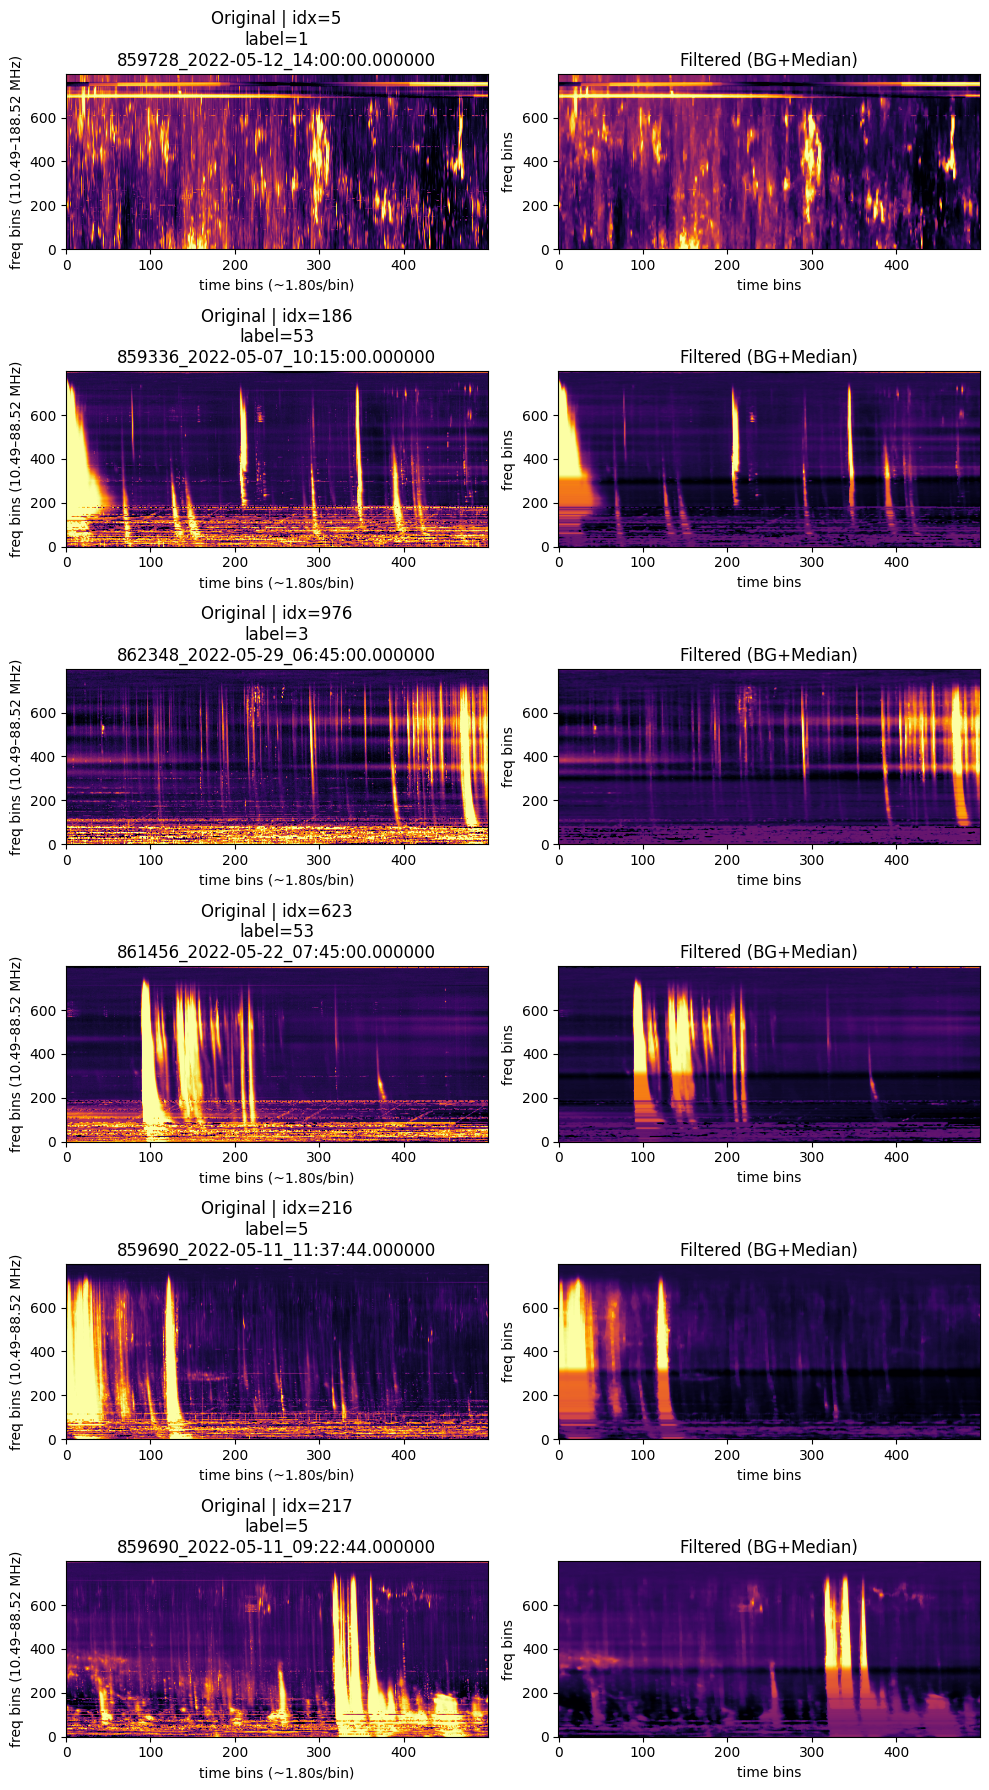


Saved filtered file:
  ../../project/lofarsw/Data/Dynspec/labelled_datasetlabeled_bgmed_filtered.h5


In [3]:
# === FULL-DATA FILTER & SAVE (keeps your settings exactly) ===
# Requires: mitigate_background_42, to_int_label, pick_kernel_for_multilabel, MEDIAN_KERNELS_DEFAULT,
#           APPLY_MEDIAN, k, T_short_s, use_robust, f_cut_MHz, low_band_fraction, ramp_df_MHz,
#           DATA_KEY, LABELS_KEY, TS_KEY, FREQ_RANGE_KEY, h5_path, CMAP, SAMPLE_IDXS
import os, sys, time, math
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ---------- Paths ----------
SRC_H5 = h5_path
OUT_SUFFIX = "labeled_bgmed_filtered.h5"

def out_path_for(src_path: str, suffix: str = OUT_SUFFIX) -> str:
    d, b = os.path.split(src_path)
    stem, ext = os.path.splitext(b)
    return os.path.join(d, stem + suffix)

DST_H5 = out_path_for(SRC_H5, OUT_SUFFIX)

# ---------- Small utilities ----------
def copy_attrs(src_obj, dst_obj):
    for k, v in src_obj.attrs.items():
        dst_obj.attrs[k] = v

def copy_tree_except_data(src_grp, dst_grp, data_key=DATA_KEY):
    """Recursively copy everything except dataset named `data_key` at each level."""
    copy_attrs(src_grp, dst_grp)
    for name, item in src_grp.items():
        if isinstance(item, h5py.Dataset):
            if name == data_key and item.parent == src_grp:
                # Skip copying 'data' here; we'll write filtered data later.
                continue
            # Copy small side datasets fully (RAM is fine on HPC)
            dset = dst_grp.create_dataset(
                name,
                data=item[...],
                dtype=item.dtype,
                compression=item.compression if item.compression else None,
                shuffle=getattr(item, "shuffle", None),
                fletcher32=getattr(item, "fletcher32", None),
                chunks=item.chunks
            )
            copy_attrs(item, dset)
        elif isinstance(item, h5py.Group):
            new_grp = dst_grp.create_group(name)
            copy_tree_except_data(item, new_grp, data_key=data_key)

def make_progress(total, bar_len=30):
    start = time.time()
    def _update(i):
        frac = (i + 1) / total
        filled = int(bar_len * frac)
        bar = "█" * filled + "-" * (bar_len - filled)
        elapsed = time.time() - start
        itps = (i + 1) / max(elapsed, 1e-6)
        eta = (total - (i + 1)) / max(itps, 1e-6)
        sys.stdout.write(f"\r[{bar}] {i+1}/{total}  {itps:5.1f} it/s  ETA {eta:5.1f}s")
        sys.stdout.flush()
        if i + 1 == total:
            sys.stdout.write("\n")
    return _update

def safe_pick_kernel(lbl):
    # Multi-label first (e.g., "135"), otherwise single int label 1..6
    try:
        return pick_kernel_for_multilabel(lbl)
    except Exception:
        try:
            t = to_int_label(lbl)
            return MEDIAN_KERNELS_DEFAULT.get(t, MEDIAN_KERNELS_DEFAULT[6])
        except Exception:
            return MEDIAN_KERNELS_DEFAULT[6]

# ---------- Run full filtering and save ----------
print(f"Source:   {SRC_H5}")
print(f"Writing:  {DST_H5}")

with h5py.File(SRC_H5, "r") as fr, h5py.File(DST_H5, "w") as fw:
    # Copy everything but 'data'
    copy_tree_except_data(fr, fw, data_key=DATA_KEY)

    # Pull required datasets + meta
    src_data = fr[DATA_KEY]
    N, H, W = src_data.shape
    labels_ds = fr.get(LABELS_KEY, None)
    ts_ds = fr.get(TS_KEY, None)
    freq_ranges_ds = fr.get(FREQ_RANGE_KEY, None)

    # Allocate full output in RAM (HPC node)
    filtered = np.empty((N, H, W), dtype=np.float32)

    # Progress
    update = make_progress(N)

    for i in range(N):
        Ic = np.asarray(src_data[i], dtype=np.float32)
        frng = np.asarray(freq_ranges_ds[i]) if freq_ranges_ds is not None else np.array([10.5, 88.5], dtype=np.float32)

        # Guard invalid frames; keep original if broken
        if not np.isfinite(Ic).all() or Ic.max() <= Ic.min():
            filtered[i] = np.clip(Ic, 0.0, None).astype(np.float32)
            update(i); continue

        # Background mitigation (your exact settings/logic preserved)
        Ir, _ = mitigate_background_42(
            Ic,
            frng,
            k=k,
            T_short_s=T_short_s,
            use_robust=use_robust,
            f_cut_MHz=f_cut_MHz,
            low_band_fraction=low_band_fraction,
            ramp_df_MHz=ramp_df_MHz,
            bias_match_highband=True,
            return_scaled=False
        )

        If = Ir
        if 'APPLY_MEDIAN' in globals() and APPLY_MEDIAN:
            ker = safe_pick_kernel(labels_ds[i]) if labels_ds is not None and i < len(labels_ds) else MEDIAN_KERNELS_DEFAULT[6]
            from scipy.ndimage import median_filter
            If = median_filter(Ir, size=ker, mode='nearest')
            If = np.clip(If, 0.0, None)

        filtered[i] = If.astype(np.float32)
        update(i)

    # Create output data set and write in one go (RAM is available)
    dset_out = fw.create_dataset(
        DATA_KEY,
        data=filtered,
        dtype=np.float32,
        compression="gzip",  # keep it compressed; adjust if you want raw speed over size
        chunks=(1, H, W)     # friendly for random reads later
    )
    # Preserve attrs from original data
    copy_attrs(fr[DATA_KEY], dset_out)
    dset_out.attrs["filtered_stage"] = np.string_("background+median" if ('APPLY_MEDIAN' in globals() and APPLY_MEDIAN) else "background_only")
    dset_out.attrs["paper_section"] = np.string_("4.2 background mitigation (soft low-band cross-fade)")

print("Done. New filtered dataset saved.")

# ---------- Quick visual check: show a few ORIGINAL vs FILTERED samples ----------
def _safe_to_str(x):
    try:
        return x.decode()
    except Exception:
        return str(x)

try:
    with h5py.File(SRC_H5, "r") as f0, h5py.File(DST_H5, "r") as f1:
        data0 = f0[DATA_KEY]
        data1 = f1[DATA_KEY]
        ts0 = f0.get(TS_KEY, None)
        fr0 = f0.get(FREQ_RANGE_KEY, None)
        lbl0 = f0.get(LABELS_KEY, None)

        # Choose indices: prefer your SAMPLE_IDXS; fall back to first few
        idxs = [i for i in (SAMPLE_IDXS if 'SAMPLE_IDXS' in globals() else list(range(8))) if 0 <= i < len(data0)]
        idxs = idxs[:6] if len(idxs) > 6 else idxs
        if not idxs:
            idxs = list(range(min(6, len(data0))))

        sec_per_col = 900.0 / float(data0.shape[2])

        n = len(idxs)
        fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(10, 3*n))
        if n == 1:
            axes = np.array([axes])

        for r, i in enumerate(idxs):
            Ic = np.asarray(data0[i], dtype=np.float32)
            If = np.asarray(data1[i], dtype=np.float32)
            fr = np.asarray(fr0[i]) if fr0 is not None else np.array([10.5, 88.5], dtype=np.float32)
            ts_str = _safe_to_str(ts0[i]) if ts0 is not None else ""
            lbl_str = _safe_to_str(lbl0[i]) if lbl0 is not None else "?"

            # Optional: use filtered stats for consistent display
            vmin, vmax = np.percentile(If, [1.0, 99.0])
            a0 = axes[r, 0]
            a0.imshow(Ic, aspect='auto', origin='lower', cmap=CMAP, vmin=vmin, vmax=vmax)
            a0.set_title(f"Original | idx={i}\nlabel={lbl_str}\n{ts_str}")
            a0.set_xlabel(f"time bins (~{sec_per_col:.2f}s/bin)")
            a0.set_ylabel(f'freq bins ({fr[0]:.2f}–{fr[1]:.2f} MHz)')

            a1 = axes[r, 1]
            a1.imshow(If, aspect='auto', origin='lower', cmap=CMAP, vmin=vmin, vmax=vmax)
            a1.set_title("Filtered (BG" + ("+Median" if ('APPLY_MEDIAN' in globals() and APPLY_MEDIAN) else "") + ")")
            a1.set_xlabel("time bins")
            a1.set_ylabel('freq bins')

        plt.tight_layout()
        plt.show()
except Exception as e:
    print("Visualization skipped due to error:", e)

print(f"\nSaved filtered file:\n  {DST_H5}")


/home/lofarsw-aaditya/test_venv/lib64/python3.9/site-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


=== Test Set Shape ===
Samples: 1002  Num classes: 6
Class order: ['Type 1', 'Type 2', 'Type 3', 'Type 4', 'Type 5', 'Nothing (6)']

=== Confusion-style counts per class ===
Type 1       | TP   86 FP  473 FN   18 TN  425
Type 2       | TP    8 FP  205 FN    4 TN  785
Type 3       | TP  463 FP  180 FN   25 TN  334
Type 4       | TP   42 FP  245 FN   17 TN  698
Type 5       | TP   37 FP  253 FN    5 TN  707
Nothing (6)  | TP  336 FP   54 FN   45 TN  567

=== Per-class metrics ===
Type 1       | P=0.154 R=0.827 F1=0.259 | support=104
Type 2       | P=0.038 R=0.667 F1=0.071 | support=12
Type 3       | P=0.720 R=0.949 F1=0.819 | support=488
Type 4       | P=0.146 R=0.712 F1=0.243 | support=59
Type 5       | P=0.128 R=0.881 F1=0.223 | support=42
Nothing (6)  | P=0.862 R=0.882 F1=0.872 | support=381
micro    avg | P=0.408 R=0.895 F1=0.561
macro    avg | P=0.341 R=0.820 F1=0.414
weighted avg | P=0.654 R=0.895 F1=0.721
samples  avg | P=0.576 R=0.900 F1=0.654

Subset accuracy (exact match): 0.38

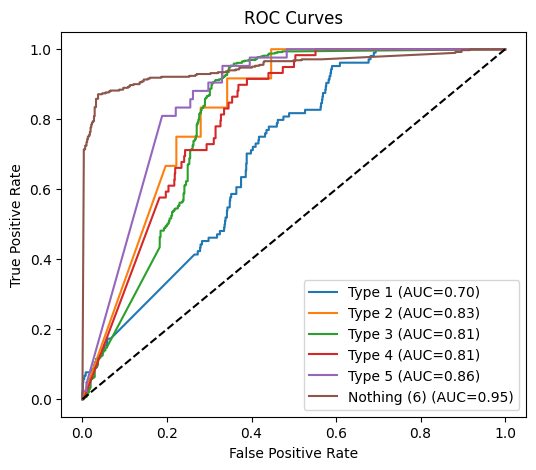

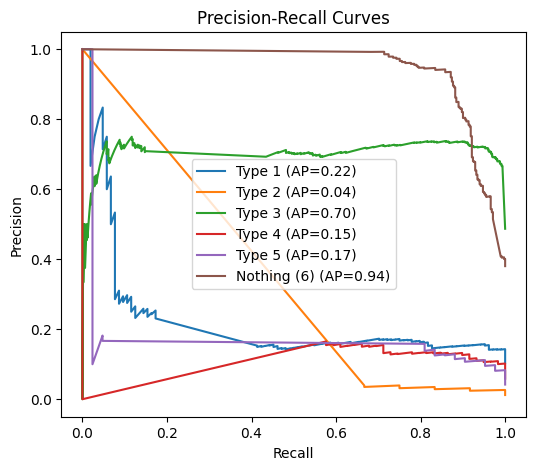

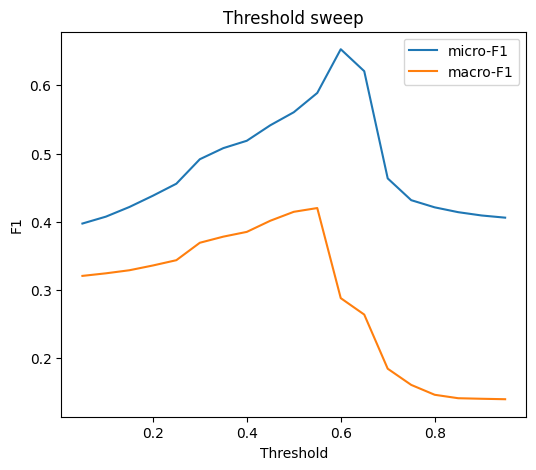


=== High-confidence correct predictions ===
Sample 253 | true=[5] | pred=[5] | probs=[0. 0. 0. 0. 0. 1.]
Sample 605 | true=[5] | pred=[5] | probs=[0. 0. 0. 0. 0. 1.]
Sample 604 | true=[5] | pred=[5] | probs=[0. 0. 0. 0. 0. 1.]
Sample 603 | true=[5] | pred=[5] | probs=[0. 0. 0. 0. 0. 1.]
Sample 600 | true=[5] | pred=[5] | probs=[0. 0. 0. 0. 0. 1.]

=== High-confidence mistakes ===
Sample 910 | true=[2 5] | pred=[5] | probs=[0. 0. 0. 0. 0. 1.]
Sample 775 | true=[2] | pred=[5] | probs=[0. 0. 0. 0. 0. 1.]
Sample 648 | true=[2] | pred=[5] | probs=[0. 0. 0. 0. 0. 1.]
Sample 439 | true=[2] | pred=[5] | probs=[0.001 0.    0.022 0.    0.    0.996]
Sample 386 | true=[0] | pred=[5] | probs=[0.002 0.    0.042 0.    0.    0.99 ]


In [3]:
# %% ========================== IN-DEPTH EVALUATION ==========================
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_fscore_support, roc_auc_score,
    roc_curve, average_precision_score, precision_recall_curve
)

@torch.no_grad()
def get_all_outputs(model, loader):
    """Run model on entire loader and collect targets, probs, preds."""
    model.eval()
    all_targets, all_logits = [], []
    for imgs, targets in loader:
        imgs = torch.nan_to_num(imgs, nan=0.0, posinf=1.0, neginf=0.0).to(device)
        targets = targets.to(device)
        logits = model(imgs)
        all_targets.append(targets.cpu())
        all_logits.append(logits.cpu())
    all_targets = torch.cat(all_targets, dim=0).numpy()
    all_logits  = torch.cat(all_logits,  dim=0).numpy()
    all_probs   = 1/(1+np.exp(-all_logits))  # sigmoid
    return all_targets, all_probs

# Gather outputs
y_true, y_prob = get_all_outputs(model, test_loader)
y_pred = (y_prob >= THRESHOLD).astype(int)

# %% -------- Basic counts --------
print("=== Test Set Shape ===")
print("Samples:", y_true.shape[0], " Num classes:", y_true.shape[1])
print("Class order:", CLASS_NAMES)

TP = ((y_true == 1) & (y_pred == 1)).sum(axis=0)
FP = ((y_true == 0) & (y_pred == 1)).sum(axis=0)
FN = ((y_true == 1) & (y_pred == 0)).sum(axis=0)
TN = ((y_true == 0) & (y_pred == 0)).sum(axis=0)

print("\n=== Confusion-style counts per class ===")
for i, cname in enumerate(CLASS_NAMES):
    print(f"{cname:12s} | TP {TP[i]:4d} FP {FP[i]:4d} FN {FN[i]:4d} TN {TN[i]:4d}")

# %% -------- Precision / Recall / F1 --------
prec, rec, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None, zero_division=0
)

print("\n=== Per-class metrics ===")
for i, cname in enumerate(CLASS_NAMES):
    print(f"{cname:12s} | P={prec[i]:.3f} R={rec[i]:.3f} F1={f1[i]:.3f} | support={int(support[i])}")

for avg in ["micro", "macro", "weighted", "samples"]:
    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, average=avg, zero_division=0
    )
    print(f"{avg:8s} avg | P={p:.3f} R={r:.3f} F1={f:.3f}")

# %% -------- Hamming & Subset accuracy --------
subset_acc = (y_true == y_pred).all(axis=1).mean()
hamming_acc = (y_true == y_pred).mean()
print(f"\nSubset accuracy (exact match): {subset_acc:.3f}")
print(f"Hamming accuracy (label-wise avg): {hamming_acc:.3f}")

# %% -------- ROC AUC & PR AUC --------
print("\n=== ROC AUC and PR AUC per class ===")
roc_aucs, pr_aucs = [], []
for i, cname in enumerate(CLASS_NAMES):
    try:
        roc_auc = roc_auc_score(y_true[:, i], y_prob[:, i])
    except ValueError:
        roc_auc = np.nan
    try:
        pr_auc = average_precision_score(y_true[:, i], y_prob[:, i])
    except ValueError:
        pr_auc = np.nan
    roc_aucs.append(roc_auc); pr_aucs.append(pr_auc)
    print(f"{cname:12s} | ROC AUC={roc_auc:.3f} PR AUC={pr_auc:.3f}")

print("Macro ROC AUC:", np.nanmean(roc_aucs), " Macro PR AUC:", np.nanmean(pr_aucs))

# %% -------- ROC curves --------
plt.figure(figsize=(6,5))
for i, cname in enumerate(CLASS_NAMES):
    if len(np.unique(y_true[:,i])) < 2: continue
    fpr, tpr, _ = roc_curve(y_true[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f"{cname} (AUC={roc_aucs[i]:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves"); plt.legend(); plt.show()

# %% -------- PR curves --------
plt.figure(figsize=(6,5))
for i, cname in enumerate(CLASS_NAMES):
    if len(np.unique(y_true[:,i])) < 2: continue
    precs, recs, _ = precision_recall_curve(y_true[:, i], y_prob[:, i])
    plt.plot(recs, precs, label=f"{cname} (AP={pr_aucs[i]:.2f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curves"); plt.legend(); plt.show()

# %% -------- Threshold sweep --------
ths = np.linspace(0.05,0.95,19)
micro_f1s, macro_f1s = [], []
for t in ths:
    yp = (y_prob >= t).astype(int)
    p,r,f,_ = precision_recall_fscore_support(y_true, yp, average="micro", zero_division=0)
    micro_f1s.append(f)
    p,r,f,_ = precision_recall_fscore_support(y_true, yp, average="macro", zero_division=0)
    macro_f1s.append(f)

plt.figure(figsize=(6,5))
plt.plot(ths, micro_f1s, label="micro-F1")
plt.plot(ths, macro_f1s, label="macro-F1")
plt.xlabel("Threshold"); plt.ylabel("F1"); plt.legend(); plt.title("Threshold sweep")
plt.show()

# %% -------- Sample-wise inspection --------
# show top 5 confident correct predictions and top 5 confident mistakes
confidences = y_prob.max(axis=1)
correct_mask = (y_true == y_pred).all(axis=1)
wrong_mask   = ~correct_mask

top_correct_idx = np.argsort(-confidences * correct_mask)[:5]
top_wrong_idx   = np.argsort(-confidences * wrong_mask)[:5]

print("\n=== High-confidence correct predictions ===")
for idx in top_correct_idx:
    print(f"Sample {idx} | true={np.where(y_true[idx])[0]} | pred={np.where(y_pred[idx])[0]} | probs={np.round(y_prob[idx],3)}")

print("\n=== High-confidence mistakes ===")
for idx in top_wrong_idx:
    print(f"Sample {idx} | true={np.where(y_true[idx])[0]} | pred={np.where(y_pred[idx])[0]} | probs={np.round(y_prob[idx],3)}")
